In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from adjustText import adjust_text
from nba_api.stats.static import players
from nba_api.stats.endpoints import (
    leaguedashplayerstats, leaguedashplayerclutch, playerawards,
)


In [4]:
pd.set_option('display.max_columns', None, 'display.max_rows', None)

## Data Collection
### Active player roster
`players.get_active_players()` reads a local static file — no network call.
Used here only as a denominator to show how many players the volume filter removes.

In [5]:
active_players_df = pd.DataFrame(players.get_active_players())
active_players_df.sample(5)


,id,full_name,first_name,last_name,is_active
76,1630619,Moussa Cisse,Moussa,Cisse,True
383,1630193,Immanuel Quickley,Immanuel,Quickley,True
141,1628368,De'Aaron Fox,De'Aaron,Fox,True
465,1626157,Karl-Anthony Towns,Karl-Anthony,Towns,True
395,1642258,Zaccharie Risacher,Zaccharie,Risacher,True


### Endpoint parameters
Named variables instead of repeated string literals — change the season in one
place, and typos raise `NameError` immediately instead of failing silently
inside an API call. `"Advanced"` and `"Base"` are two measure types of the same
endpoint: Advanced gives rate/efficiency stats, Base gives counting stats.

In [6]:
recent_season = "2025-26"
reg_season = "Regular Season"
advanced_stats = "Advanced"
basic_stats = "Base"


### Season stats — Advanced
Source for TS%, eFG%, USG%, Net Rating, PIE.

**Scale warning:** percentage columns aren't consistently scaled — some come
back as whole numbers, some as decimals. Always run `.describe()` before
binning a column; a scale mismatch doesn't error, it silently produces empty bins.

*`MIN` here is per-game. In the Base frame it's a season total — don't mix them.*

In [7]:

player_stats_advanced = leaguedashplayerstats.LeagueDashPlayerStats(
    season=recent_season,
    season_type_all_star=reg_season,
    measure_type_detailed_defense=advanced_stats
)

player_stats_advanced_df = player_stats_advanced.get_data_frames()[0]
player_stats_advanced_df.sample(5)

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM,FGA,FGM_PG,FGA_PG,FG_PCT,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,E_OFF_RATING_RANK,OFF_RATING_RANK,sp_work_OFF_RATING_RANK,E_DEF_RATING_RANK,DEF_RATING_RANK,sp_work_DEF_RATING_RANK,E_NET_RATING_RANK,NET_RATING_RANK,sp_work_NET_RATING_RANK,AST_PCT_RANK,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,E_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,USG_PCT_RANK,E_USG_PCT_RANK,E_PACE_RANK,PACE_RANK,sp_work_PACE_RANK,PIE_RANK,FGM_RANK,FGA_RANK,FGM_PG_RANK,FGA_PG_RANK,FG_PCT_RANK,TEAM_COUNT
138,1627749,Dejounte Murray,Dejounte,1610612740,NOP,29.0,14,5,9,0.357,27.8,115.4,116.2,116.2,113.9,114.9,114.9,1.5,1.3,1.3,0.336,1.89,26.6,0.011,0.188,0.101,14.1,13.9,0.536,0.580,0.267,0.274,101.61,100.83,84.02,100.83,0.138,822,88,182,6.3,13.0,0.484,472,474,116,406,132,129,117,117,352,382,382,211,221,221,22,245,82,545,77,175,520,515,309,262,38,38,323,372,372,54,356,365,70,78,202,1
365,1641778,Leaky Black,Leaky,1610612764,WAS,27.0,15,1,14,0.067,28.9,108.5,109.6,109.6,120.1,119.5,119.5,-11.6,-9.9,-9.9,0.064,1.57,15.4,0.032,0.140,0.084,9.8,9.8,0.481,0.498,0.113,0.115,103.89,103.63,86.36,103.63,0.051,931,40,103,2.7,6.9,0.388,465,549,175,566,113,410,372,372,521,507,507,516,476,476,523,342,354,332,194,258,274,278,473,499,531,533,140,154,154,524,433,421,311,253,498,1
351,204001,Kristaps Porziņģis,Kristaps,1610612744,GSW,30.0,32,13,19,0.406,24.0,114.2,113.8,113.8,111.5,110.8,110.8,2.8,3.0,3.0,0.162,1.98,13.9,0.050,0.158,0.104,7.0,7.1,0.515,0.582,0.265,0.273,103.14,103.63,86.36,103.63,0.124,1658,173,388,5.4,12.1,0.446,400,384,236,381,205,161,195,195,236,200,200,175,175,175,201,223,413,210,140,161,89,89,390,251,40,39,198,155,155,84,247,236,105,91,332,2
100,1642262,Cody Williams,Cody,1610612762,UTA,21.0,67,16,51,0.239,24.3,110.7,110.9,110.9,121.3,121.4,121.4,-10.7,-10.6,-10.6,0.111,1.88,17.7,0.036,0.084,0.059,9.4,9.5,0.495,0.524,0.159,0.161,105.17,105.04,87.53,105.04,0.057,3561,238,509,3.6,7.6,0.468,147,348,565,500,199,322,319,319,533,538,538,500,488,488,322,247,274,301,462,424,251,253,446,453,354,369,74,79,79,502,176,179,221,224,255,1
541,1641998,Trey Jemison III,Trey,1610612752,NYK,26.0,13,10,3,0.769,6.3,101.0,96.1,96.1,117.3,112.9,112.9,-16.3,-16.8,-16.8,0.088,0.50,20.0,0.086,0.118,0.101,40.0,39.3,0.600,0.623,0.099,0.107,100.52,105.02,87.51,105.02,0.027,179,6,10,0.5,0.8,0.600,480,411,44,34,538,540,553,553,478,284,284,546,544,544,425,551,208,88,293,172,582,582,98,117,561,554,395,81,81,562,528,543,560,573,49,1


### Season stats — Base
Source for FGA, FG3A, FTA, PTS, PLUS_MINUS, REB, AST. `FGA` drives the volume filter below.

In [8]:
player_stats_basic = leaguedashplayerstats.LeagueDashPlayerStats(
    season=recent_season,
    season_type_all_star=reg_season,
    measure_type_detailed_defense=basic_stats
)

player_stats_basic_df = player_stats_basic.get_data_frames()[0]
player_stats_basic_df.sample(5)

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,FGM_RANK,FGA_RANK,FG_PCT_RANK,FG3M_RANK,FG3A_RANK,FG3_PCT_RANK,FTM_RANK,FTA_RANK,FT_PCT_RANK,OREB_RANK,DREB_RANK,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
301,1628404,Josh Hart,Josh,1610612752,NYK,31.0,66,44,22,0.667,1993.575000,301,592,0.508,100,242,0.413,90,125,0.720,93,393,486,317,128,75,17,37,165,136,792,210,1998.7,13,2,1879.0,157,67,279,106,80,123,141,141,120,156,66,169,154,391,85,27,34,45,65,67,233,473,519,124,131,63,81,42,16,81,1
73,1631126,Caleb Love,Caleb,1610612757,POR,24.0,49,24,25,0.490,1012.608333,190,490,0.388,93,292,0.318,36,49,0.735,25,89,114,123,62,27,4,34,48,36,509,-127,861.3,0,0,901.0,305,252,326,333,275,223,186,500,139,109,366,326,322,368,336,328,341,193,217,300,418,453,208,360,233,478,284,284,38,264,1
120,1642450,Daniss Jenkins,Daniss,1610612765,DET,24.0,72,54,18,0.750,1455.300000,232,568,0.408,73,195,0.374,134,161,0.832,51,115,166,278,115,64,15,51,107,146,671,209,1409.2,3,0,1346.0,84,13,225,46,175,180,150,455,182,198,171,107,116,167,201,282,269,65,90,94,251,531,362,109,165,64,165,128,38,168,1
375,1628436,Luke Kornet,Luke,1610612759,SAS,30.0,68,52,16,0.765,1430.080000,175,272,0.643,0,0,0.000,94,114,0.825,181,233,414,126,28,32,65,18,120,125,444,118,1392.8,3,0,1178.0,135,24,202,38,183,246,304,30,517,548,517,161,174,189,18,112,58,185,363,276,36,313,397,137,256,106,167,128,38,200,1
360,1629013,Landry Shamet,Landry,1610612752,NYK,29.0,51,35,16,0.686,1171.055000,159,364,0.437,103,263,0.392,54,76,0.711,23,69,92,72,30,31,9,18,77,81,475,191,783.4,0,0,822.0,291,162,202,90,243,264,246,362,112,127,116,261,256,409,345,360,364,301,353,279,315,313,286,229,247,76,302,284,38,290,1


### Clutch stats — Advanced
Same endpoint, restricted to clutch possessions: `clutch_time='Last 5 Minutes'`,
`point_diff=5`, `ahead_behind='Ahead or Behind'` — together these reproduce the
NBA's official clutch definition.

In [9]:
clutch_advanced = leaguedashplayerclutch.LeagueDashPlayerClutch(
    season=recent_season,
    season_type_all_star=reg_season,
    measure_type_detailed_defense=advanced_stats,
    clutch_time='Last 5 Minutes',
    ahead_behind='Ahead or Behind',
    point_diff=5
)
clutch_adv_df = clutch_advanced.get_data_frames()[0]

### Volume filter — 100+ FGA
Two jobs: analytically, rate stats are unstable at low volume (12 shots at 70%
means nothing); practically, it shrinks the player list before the awards loop,
which needs one API call per player.

In [10]:
volume_mask = player_stats_basic_df['FGA'] > 100
player_ids = player_stats_basic_df.loc[volume_mask, 'PLAYER_ID'].tolist()

print(f"{len(player_ids)} players (down from {len(active_players_df)})")

423 players (down from 530)


### Career awards — per-player fetch
**Slow cell — run once.** `PlayerAwards` takes one player at a time; there's no
league-wide equivalent, so this can't be sped up with masking — the bottleneck
is network I/O, not computation.

- `time.sleep(0.6)` throttles the loop to avoid rate limiting on an unofficial endpoint
- `if not awards_df.empty` skips players with no career awards
- Progress prints every 25 players
- Result cached to Parquet so this never has to run twice

> **TODO:** add a cache check so Restart & Run All loads from disk:
> ```python
> import os
> if os.path.exists('all_awards.parquet'):
>     all_awards_df = pd.read_parquet('all_awards.parquet')
> else:
>     ...  # existing loop
> ```

In [49]:
if os.path.exists('all_awards.parquet'):
    all_awards_df = pd.read_parquet('all_awards.parquet')
    print(f"Loaded {len(all_awards_df)} award rows from cache")
else:
    awards_frames = []
    total = len(player_ids)

    for idx, pid in enumerate(player_ids, start=1):
        awards = playerawards.PlayerAwards(player_id=pid)
        awards_df = awards.get_data_frames()[0]
        if not awards_df.empty:
            awards_frames.append(awards_df)

        if idx % 25 == 0 or idx == total:
            print(f"Processed {idx}/{total} players...")

        time.sleep(0.6)

    all_awards_df = pd.concat(awards_frames, ignore_index=True)
    all_awards_df.to_parquet('all_awards.parquet')

all_awards_df.sample(5)

Loaded 1710 award rows from cache


,PERSON_ID,FIRST_NAME,LAST_NAME,TEAM,DESCRIPTION,ALL_NBA_TEAM_NUMBER,SEASON,MONTH,WEEK,CONFERENCE,TYPE,SUBTYPE1,SUBTYPE2,SUBTYPE3
724,203954,Joel,Embiid,Philadelphia 76ers,NBA Player of the Week,NaN,2017-18,NaN,2018-01-15T00:00:00,East,Award,Kia Motors,KIPWK,NaN
420,203507,Giannis,Antetokounmpo,Milwaukee Bucks,NBA Player of the Month,NaN,2019-20,12/1/2019,NaN,East,Award,Kia Motors,KIPMO,NaN
263,1628401,Derrick,White,Boston Celtics,NBA Player of the Week,NaN,2022-23,NaN,2023-02-06T00:00:00,East,Award,Kia Motors,KIPWK,NaN
569,201935,James,Harden,Brooklyn Nets,NBA Player of the Month,NaN,2020-21,3/1/2021,NaN,East,Award,Kia Motors,KIPMO,NaN
327,1628378,Donovan,Mitchell,Cleveland Cavaliers,NBA Player of the Week,NaN,2025-26,NaN,2025-11-17T00:00:00,East,Award,Kia Motors,KIPWK,NaN


## Classifying Players by Reputation
### Star tier
Star = one of five accolades **within the last 5 seasons**. Excludes
All-Defensive/All-Rookie (different kind of reputation) and Player of the
Week/Month (too frequent to signal star status). The 5-season window matters —
without it, a 2013 All-Star reads identically to a current MVP candidate.

Two boolean Series combined with `&` (element-wise AND, parenthesize each side).
`.unique()` collapses to one ID per player since stars match multiple award rows.

In [12]:
recent_seasons = ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']

star_descriptions = [
    'All-NBA',
    'NBA Most Valuable Player',
    'NBA Finals Most Valuable Player',
    'NBA All-Star Most Valuable Player',
    'NBA All-Star'
]

star_mask = (
    all_awards_df['DESCRIPTION'].isin(star_descriptions)
    & all_awards_df['SEASON'].isin(recent_seasons)
)

star_player_ids = all_awards_df.loc[star_mask, 'PERSON_ID'].unique()
print(f"{len(star_player_ids)} stars in the last 5 seasons")

57 stars in the last 5 seasons


### Great tier
Greats = Stars who also hold Olympic Gold. `np.intersect1d` returns values
present in both ID arrays.

**This tier is small (~10-13 players) — any pattern here is suggestive, not
statistically meaningful.** Not season-restricted, since Olympic Games run on a
4-year cycle and the `SEASON` tag for a summer tournament is inconsistent.

In [13]:
gold_mask = all_awards_df['DESCRIPTION'] == 'Olympic Gold Medal'
gold_medalist_ids = all_awards_df.loc[gold_mask, 'PERSON_ID'].unique()

great_player_ids = np.intersect1d(star_player_ids, gold_medalist_ids)
print(f"{len(great_player_ids)} greats")

17 greats


### Build the season master table
Joins Advanced + Base on `PLAYER_ID`, applies the volume filter, assigns tier
labels. Columns are trimmed explicitly — a naive merge produces 200+ columns
including duplicate `_RANK` fields for everything.

`np.where` nested checks `is_great` first so a Great isn't overwritten by the
Star branch (every Great is also a Star). **Record the tier counts printed
here** — they go in the Limitations section later.

In [14]:
adv_cols = ['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'MIN',
            'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'EFG_PCT', 'TS_PCT',
            'USG_PCT', 'PIE', 'POSS']
base_cols = ['PLAYER_ID', 'FGA', 'FG3A', 'FTA', 'PTS', 'PLUS_MINUS', 'REB', 'AST']

season_df = player_stats_advanced_df[adv_cols].merge(
    player_stats_basic_df[base_cols], on='PLAYER_ID', how='inner'
)

season_df = season_df[season_df['FGA'] > 100].copy()

season_df['is_star'] = season_df['PLAYER_ID'].isin(star_player_ids)
season_df['is_great'] = season_df['PLAYER_ID'].isin(great_player_ids)

# Three-way label for charts
season_df['group'] = np.where(
    season_df['is_great'], 'Great',
    np.where(season_df['is_star'], 'Star', 'Role')
)

season_df['group'].value_counts()

group
Role     366
Star      40
Great     17
Name: count, dtype: int64

### Showing Players With Olympic Gold Medals

*These players have all won at least one gold medal and is grouped with the `Great` category.*

In [15]:
great_players_df = season_df[season_df['PLAYER_ID'].isin(great_player_ids)][['PLAYER_NAME', 'TEAM_ABBREVIATION', 'group']]
great_players_df

,PLAYER_NAME,TEAM_ABBREVIATION,group
30,Anthony Davis,WAS,Great
31,Anthony Edwards,MIN,Great
39,Bam Adebayo,MIA,Great
135,DeMar DeRozan,SAC,Great
146,Devin Booker,PHX,Great
159,Draymond Green,GSW,Great
245,James Harden,CLE,Great
266,Jayson Tatum,BOS,Great
275,Jimmy Butler III,GSW,Great
279,Joel Embiid,PHI,Great


### Join clutch to season — the analysis table
`suffixes=('_SEASON','_CLUTCH')` puts matching metrics side by side so deltas
can be computed directly.

**The `GP_CLUTCH >= 15` floor is the most important line in this notebook.**
Clutch minutes are scarce — without this floor, a 15-point TS% swing from 3
clutch games would be treated as a real finding instead of noise.

`TS_DELTA` / `USG_DELTA` = clutch minus season. Positive TS_DELTA = better under pressure.

In [16]:
clutch_cols = ['PLAYER_ID', 'GP', 'MIN', 'EFG_PCT', 'TS_PCT', 'USG_PCT',
               'NET_RATING', 'PIE', 'FGA']

clutch_slim = clutch_adv_df[clutch_cols]

df = season_df.merge(clutch_slim, on='PLAYER_ID', how='inner',
                     suffixes=('_SEASON', '_CLUTCH'))

df = df[df['GP_CLUTCH'] >= 15].copy()

df['TS_DELTA'] = df['TS_PCT_CLUTCH'] - df['TS_PCT_SEASON']
df['USG_DELTA'] = df['USG_PCT_CLUTCH'] - df['USG_PCT_SEASON']

print(f"{len(df)} players with 15+ clutch games")
df['group'].value_counts()

221 players with 15+ clutch games


group
Role     174
Star      34
Great     13
Name: count, dtype: int64

## Charts/Graphs Overview
### Chart 1 — Star vs Role split
*The reputation hierarchy is steep — most rotation players have never received
a major accolade. Any "stars are clutch" claim is a claim about a small group
being systematically different, which is a high bar.*

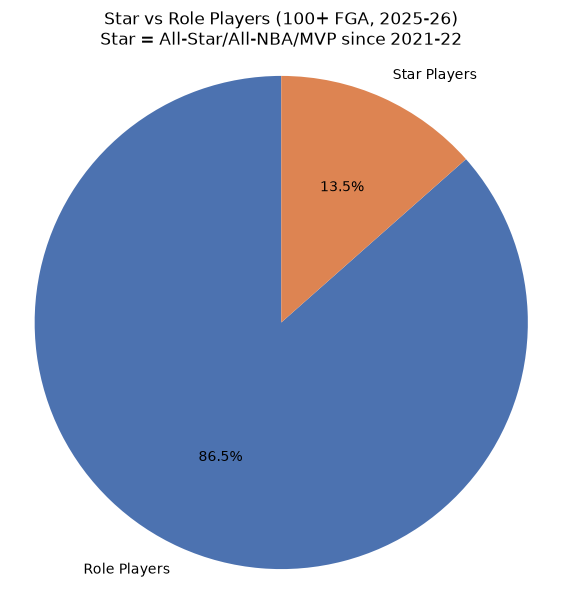

In [17]:
counts = season_df['is_star'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie([counts.get(False, 0), counts.get(True, 0)],
        labels=['Role Players', 'Star Players'],
        autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Star vs Role Players (100+ FGA, 2025-26)\nStar = All-Star/All-NBA/MVP since 2021-22')
plt.axis('equal')
plt.show()

### Chart 2 — Greats vs Stars vs Role
*The Great slice is exploded to show how thin it is — this is the sample-size
warning for the rest of the notebook.*

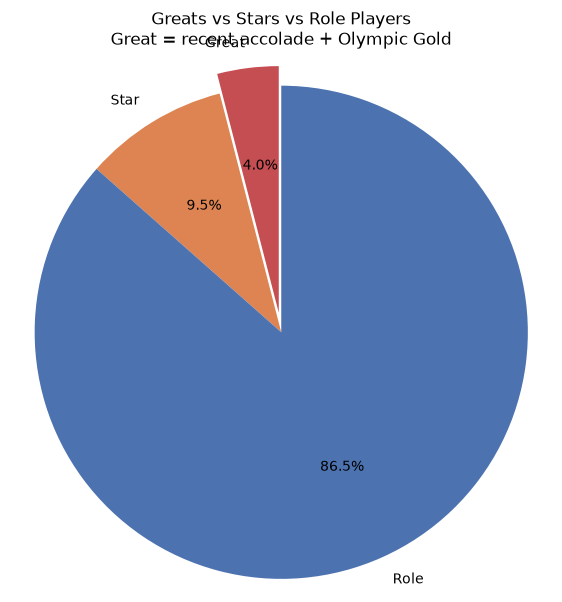

In [18]:
g = season_df['group'].value_counts().reindex(['Great', 'Star', 'Role'])
plt.figure(figsize=(7, 7))
plt.pie(g, labels=g.index, autopct='%1.1f%%',
        colors=['#C44E52', '#DD8452', '#4C72B0'],
        startangle=90, explode=(0.08, 0, 0))
plt.title('Greats vs Stars vs Role Players\nGreat = recent accolade + Olympic Gold')
plt.axis('equal')
plt.show()

## Season-Long Baseline
Establishing this first matters — without it, a clutch difference could just
mean stars are better players overall, not that pressure affects them differently.

### Chart 3 — Shooting & usage by tier
*Usage separates the tiers sharply; efficiency separates much less. That gap
between "how much they shoot" and "how well they shoot" is the thread the rest
of the notebook pulls on.*

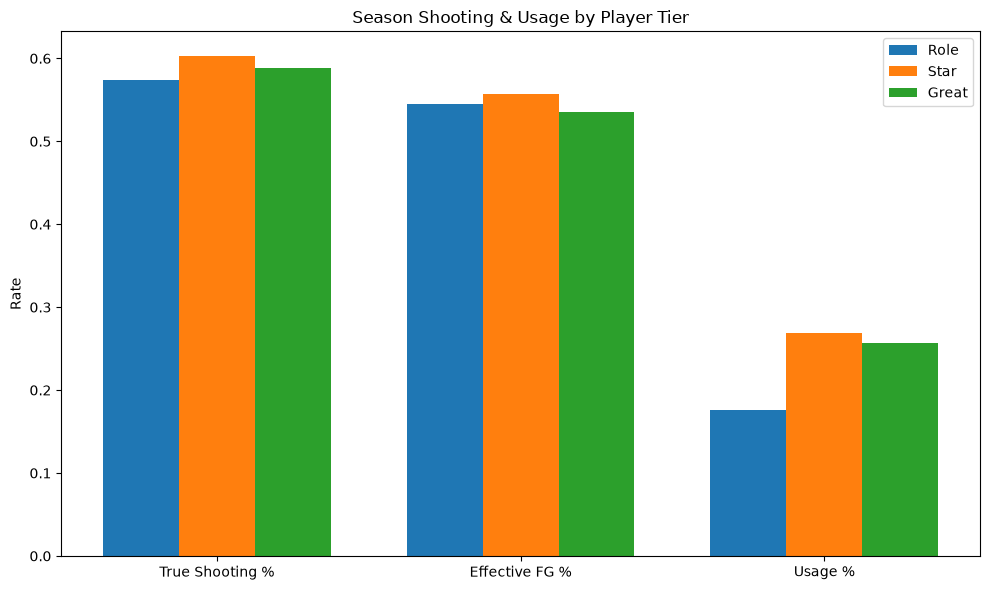

In [19]:
metrics = ['TS_PCT', 'EFG_PCT', 'USG_PCT']
grouped = season_df.groupby('group')[metrics].mean().reindex(['Role', 'Star', 'Great'])

x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
for i, grp in enumerate(grouped.index):
    ax.bar(x + i * width, grouped.loc[grp], width, label=grp)

ax.set_xticks(x + width)
ax.set_xticklabels(['True Shooting %', 'Effective FG %', 'Usage %'])
ax.set_ylabel('Rate')
ax.set_title('Season Shooting & Usage by Player Tier')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 4 — Net Rating & PIE by tier
Plotted on separate axes — their scales differ by an order of magnitude.

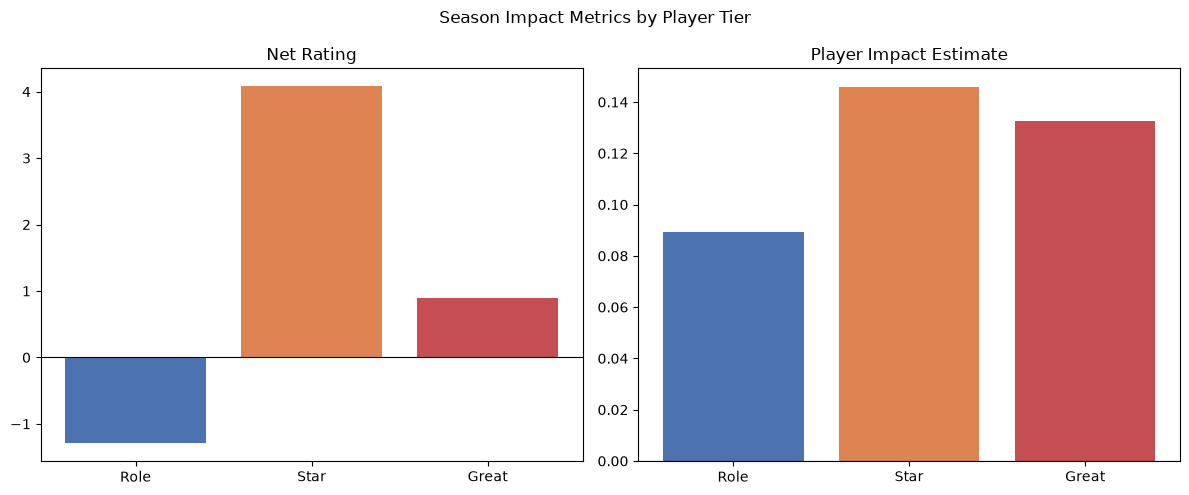

In [20]:
impact = ['NET_RATING', 'PIE']
gi = season_df.groupby('group')[impact].mean().reindex(['Role', 'Star', 'Great'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, m, title in zip(axes, impact, ['Net Rating', 'Player Impact Estimate']):
    ax.bar(gi.index, gi[m], color=['#4C72B0', '#DD8452', '#C44E52'])
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.8)
plt.suptitle('Season Impact Metrics by Player Tier')
plt.tight_layout()
plt.show()

## Clutch vs. Season
> *Does clutch efficiency match season efficiency, and does the gap differ by tier?*

### Chart 5 — Season vs clutch efficiency, by tier
*Compare each tier against itself first — that within-tier gap is the pressure
effect. Then compare gaps across tiers.*

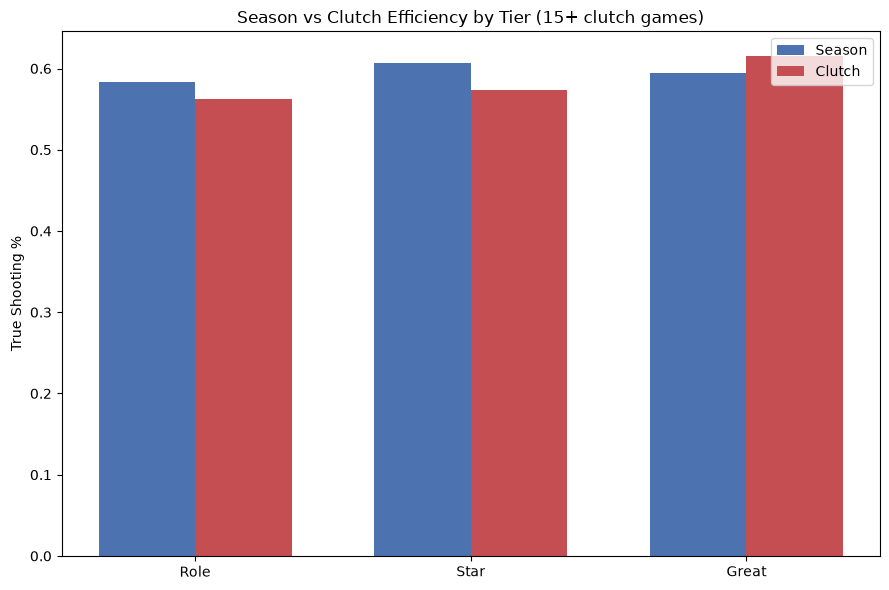

In [21]:
comp = df.groupby('group')[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].mean().reindex(['Role', 'Star', 'Great'])

x = np.arange(len(comp))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, comp['TS_PCT_SEASON'], width, label='Season', color='#4C72B0')
ax.bar(x + width/2, comp['TS_PCT_CLUTCH'], width, label='Clutch', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(comp.index)
ax.set_ylabel('True Shooting %')
ax.set_title('Season vs Clutch Efficiency by Tier (15+ clutch games)')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 6 — Player-level view of the same comparison
Dashed diagonal = no change. Above = better in clutch, below = worse.
*Averages can hide a split where half rise and half collapse. This shows
whether Chart 5's tier means reflect a real pattern.*

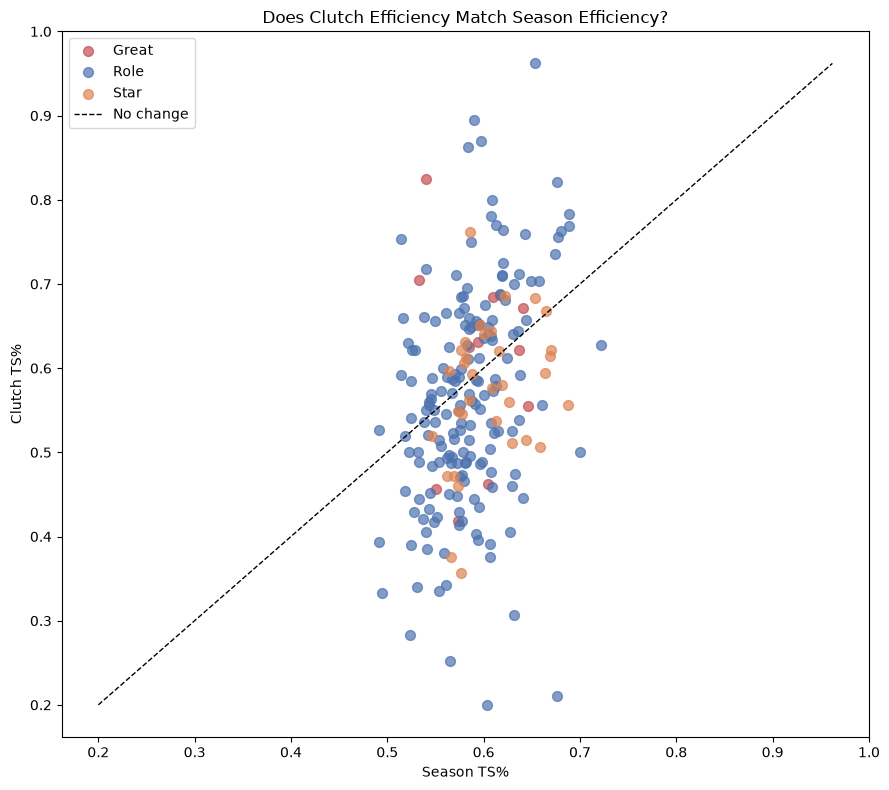

In [22]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = {'Role': '#4C72B0', 'Star': '#DD8452', 'Great': '#C44E52'}
for grp, sub in df.groupby('group'):
    ax.scatter(sub['TS_PCT_SEASON'], sub['TS_PCT_CLUTCH'],
               label=grp, alpha=0.7, s=50, color=colors[grp])

lims = [df[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].min().min(),
        df[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].max().max()]
ax.plot(lims, lims, 'k--', linewidth=1, label='No change')

ax.set_xlabel('Season TS%')
ax.set_ylabel('Clutch TS%')
ax.set_title('Does Clutch Efficiency Match Season Efficiency?')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 7 — Distribution of the pressure effect
*The width matters more than the position. Heavy overlap across tiers means
tier membership explains little of the variation.*

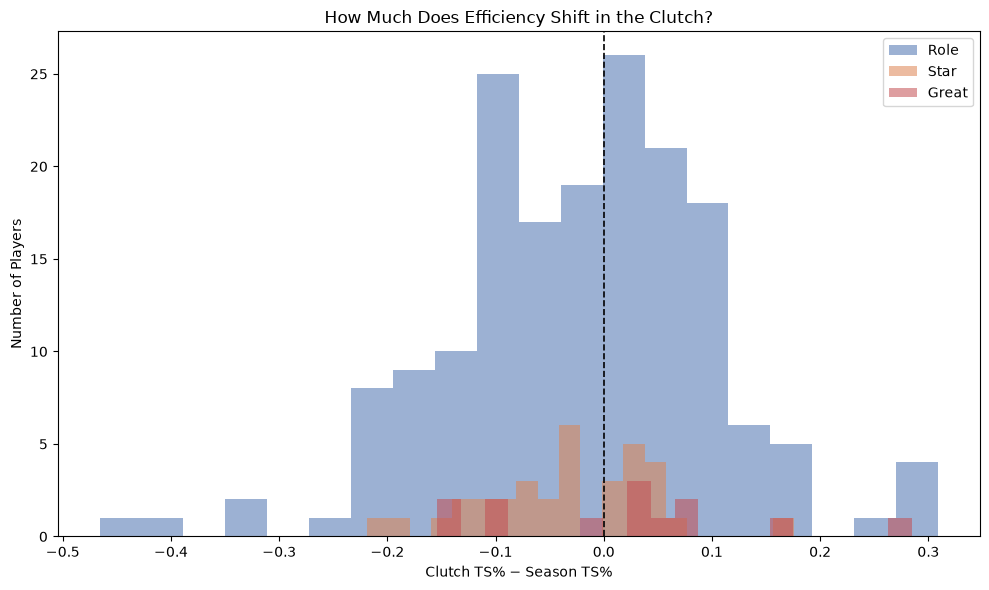

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Role': '#4C72B0', 'Star': '#DD8452', 'Great': '#C44E52'}

for grp in ['Role', 'Star', 'Great']:
    sub = df[df['group'] == grp]
    ax.hist(sub['TS_DELTA'], bins=20, alpha=0.55, label=grp, color=colors[grp])

ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('Clutch TS% − Season TS%')
ax.set_ylabel('Number of Players')
ax.set_title('How Much Does Efficiency Shift in the Clutch?')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 8 — Do stars absorb more clutch usage?
*The mechanism behind the thesis: offenses funnel late-game possessions to
their known player. If usage jumps for stars while efficiency (Chart 5) stays
flat, those extra shots are allocated on reputation, not demonstrated ability.*

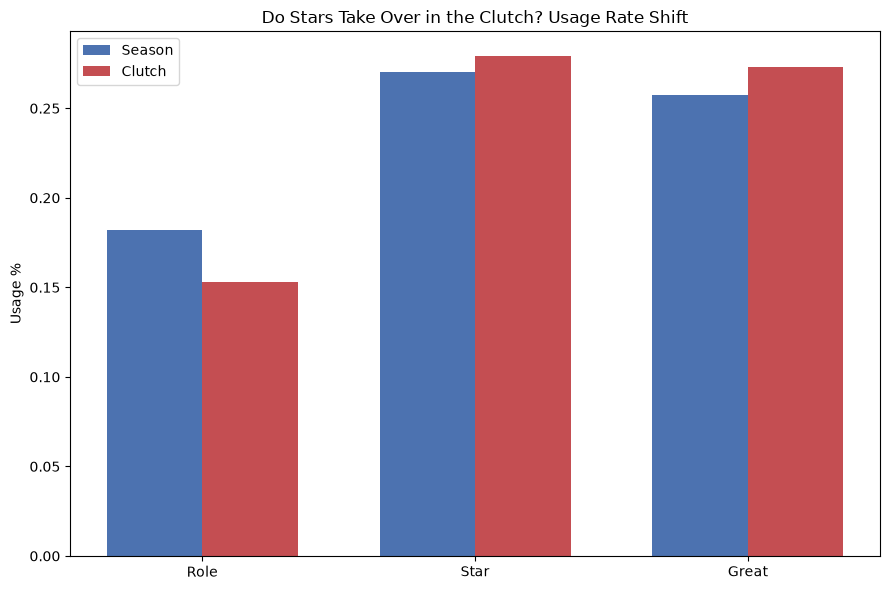

In [24]:
usg = df.groupby('group')[['USG_PCT_SEASON', 'USG_PCT_CLUTCH']].mean().reindex(['Role', 'Star', 'Great'])

x = np.arange(len(usg))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, usg['USG_PCT_SEASON'], width, label='Season', color='#4C72B0')
ax.bar(x + width/2, usg['USG_PCT_CLUTCH'], width, label='Clutch', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(usg.index)
ax.set_ylabel('Usage %')
ax.set_title('Do Stars Take Over in the Clutch? Usage Rate Shift')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 9 — Biggest clutch risers
Looking at the best clutch performers in the league.

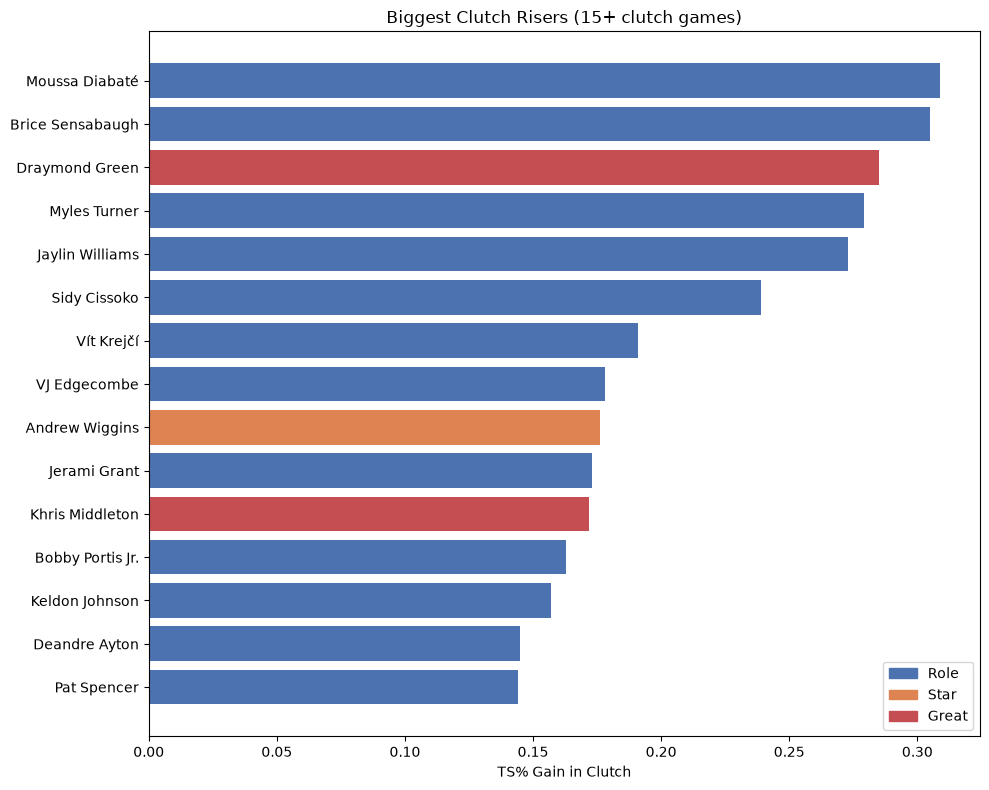

In [25]:
risers = df.nlargest(15, 'TS_DELTA')[['PLAYER_NAME', 'TS_DELTA', 'group']]

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [colors[g] for g in risers['group']]
ax.barh(risers['PLAYER_NAME'], risers['TS_DELTA'], color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel('TS% Gain in Clutch')
ax.set_title('Biggest Clutch Risers (15+ clutch games)')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys())
plt.tight_layout()
plt.show()

### Chart 10 — Biggest clutch fallers
*Present with Chart 9. If stars are overrepresented among fallers relative to
their population share, that's the strongest single piece of evidence for the
thesis — though these are distribution extremes, exactly where small samples
look biggest.*

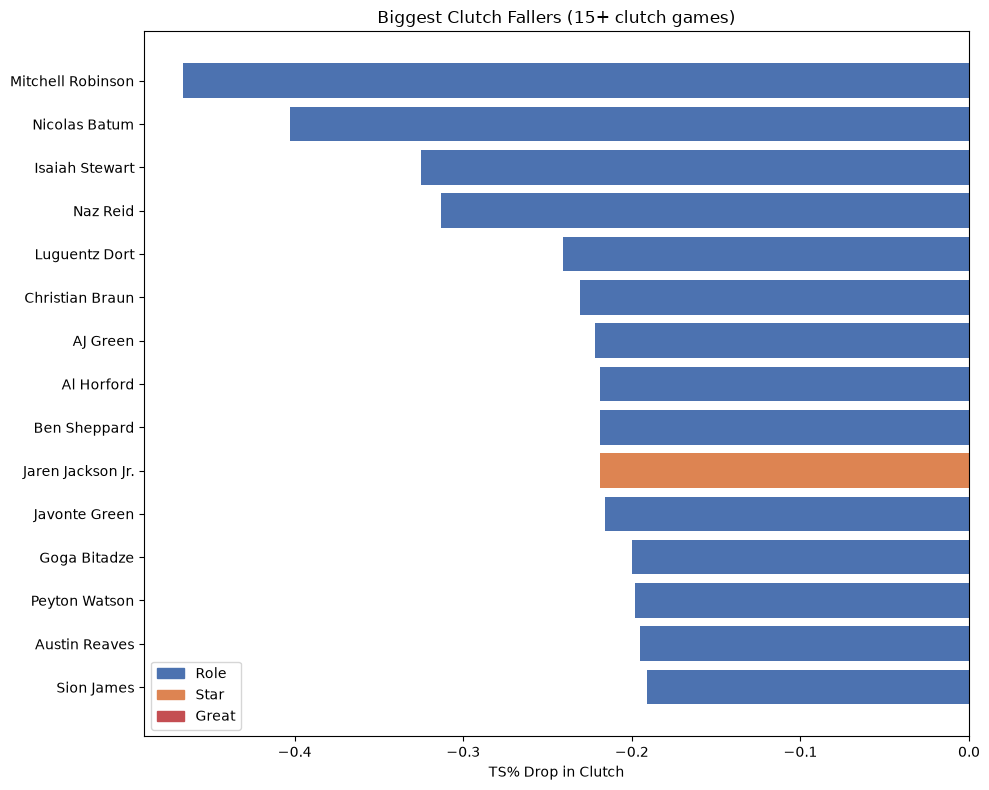

In [26]:
fallers = df.nsmallest(15, 'TS_DELTA')[['PLAYER_NAME', 'TS_DELTA', 'group']]

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [colors[g] for g in fallers['group']]
ax.barh(fallers['PLAYER_NAME'], fallers['TS_DELTA'], color=bar_colors)
ax.invert_yaxis()
ax.set_xlabel('TS% Drop in Clutch')
ax.set_title('Biggest Clutch Fallers (15+ clutch games)')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys())
plt.tight_layout()
plt.show()

### Chart 11 — Consistency under pressure
*A tier can average zero change while containing both players who reliably
rise and players who reliably collapse — a taller box means less predictable
clutch performance.*

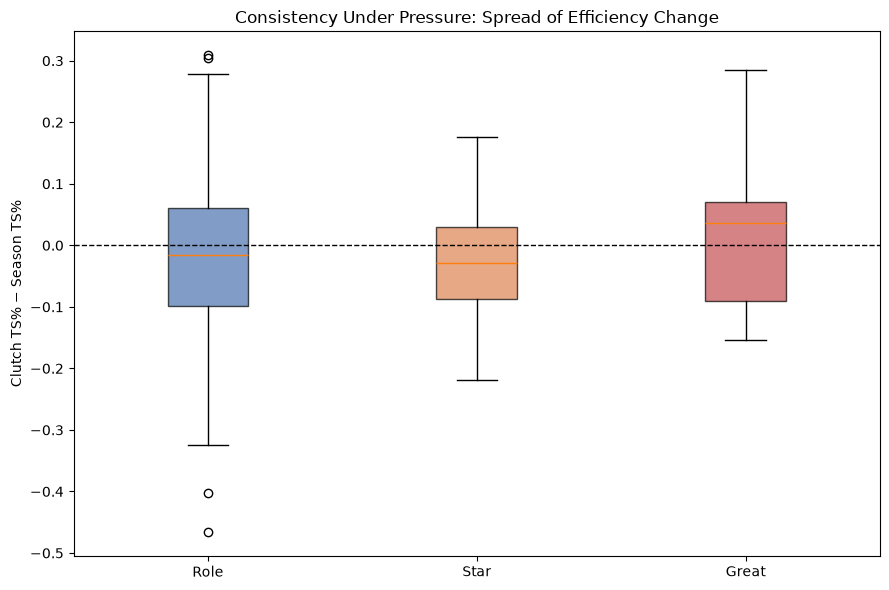

In [27]:
groups_order = ['Role', 'Star', 'Great']
data = [df.loc[df['group'] == g, 'TS_DELTA'].dropna() for g in groups_order]

fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(data, tick_labels=groups_order, patch_artist=True)

for patch, g in zip(bp['boxes'], groups_order):
    patch.set_facecolor(colors[g])
    patch.set_alpha(0.7)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Clutch TS% − Season TS%')
ax.set_title('Consistency Under Pressure: Spread of Efficiency Change')
plt.tight_layout()
plt.show()

## Home vs. Road
> *Do home/road splits show a measurable clutch difference?*

### Fetch location-split clutch data
Same clutch definition, filtered by `location_nullable`. Wrapped in a function
so the six clutch parameters live in one place.

In [28]:
def get_clutch(location=None):
    kwargs = dict(
        season=recent_season,
        season_type_all_star=reg_season,
        measure_type_detailed_defense=advanced_stats,
        clutch_time='Last 5 Minutes',
        ahead_behind='Ahead or Behind',
        point_diff=5
    )
    if location:
        kwargs['location_nullable'] = location
    return leaguedashplayerclutch.LeagueDashPlayerClutch(**kwargs).get_data_frames()[0]

home_clutch_df = get_clutch('Home')
time.sleep(1)
road_clutch_df = get_clutch('Road')

print(len(home_clutch_df), len(road_clutch_df))

457 456


### Merge splits and apply a sample floor
Self-join puts each player's home/road numbers on one row. The 8-game floor in
each location matters — splitting an already-small clutch sample by venue
halves it again. Check the printed count before trusting Charts 12–14.

In [29]:
hr_cols = ['PLAYER_ID', 'GP', 'TS_PCT', 'NET_RATING', 'USG_PCT']

hr = (home_clutch_df[hr_cols]
      .merge(road_clutch_df[hr_cols], on='PLAYER_ID', suffixes=('_HOME', '_ROAD')))

hr = hr[(hr['GP_HOME'] >= 8) & (hr['GP_ROAD'] >= 8)].copy()
hr['TS_HOME_ROAD_GAP'] = hr['TS_PCT_HOME'] - hr['TS_PCT_ROAD']

hr = hr.merge(df[['PLAYER_ID', 'PLAYER_NAME', 'group']], on='PLAYER_ID', how='inner')
print(f"{len(hr)} players with 8+ clutch games home and road")
hr['group'].value_counts()

175 players with 8+ clutch games home and road


group
Role     134
Star      31
Great     10
Name: count, dtype: int64

### Collapse to two tiers
Greats folded into Stars — a dozen players can't survive a further venue split.

In [30]:
hr['tier2'] = np.where(hr['group'] == 'Role', 'Role', 'Star')
hr['tier2'].value_counts()

tier2
Role    134
Star     41
Name: count, dtype: int64

### Chart 12 — Clutch efficiency, home vs road
Sample sizes are printed on the x-axis labels — do this on every tier chart
from here on.

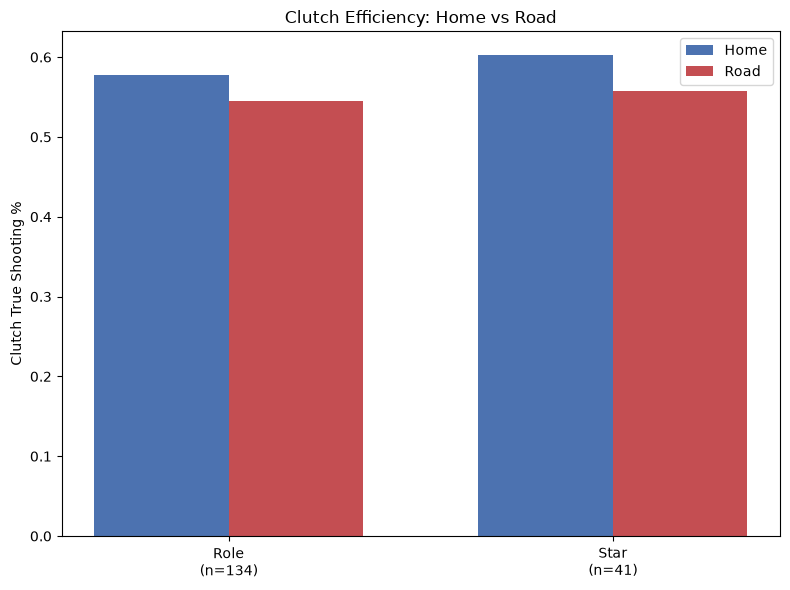

In [31]:
hr_ts = hr.groupby('tier2')[['TS_PCT_HOME', 'TS_PCT_ROAD']].mean().reindex(['Role', 'Star'])

x = np.arange(len(hr_ts))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, hr_ts['TS_PCT_HOME'], width, label='Home', color='#4C72B0')
ax.bar(x + width/2, hr_ts['TS_PCT_ROAD'], width, label='Road', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n(n={c})' for t, c in zip(hr_ts.index, hr['tier2'].value_counts().reindex(hr_ts.index))])
ax.set_ylabel('Clutch True Shooting %')
ax.set_title('Clutch Efficiency: Home vs Road')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 13 — Home vs road, player by player
*If the cloud sits symmetrically around the diagonal, home court doesn't move
clutch shooting — a clean negative answer to sub-question 3, worth stating
plainly rather than hunting for a pattern that isn't there.*

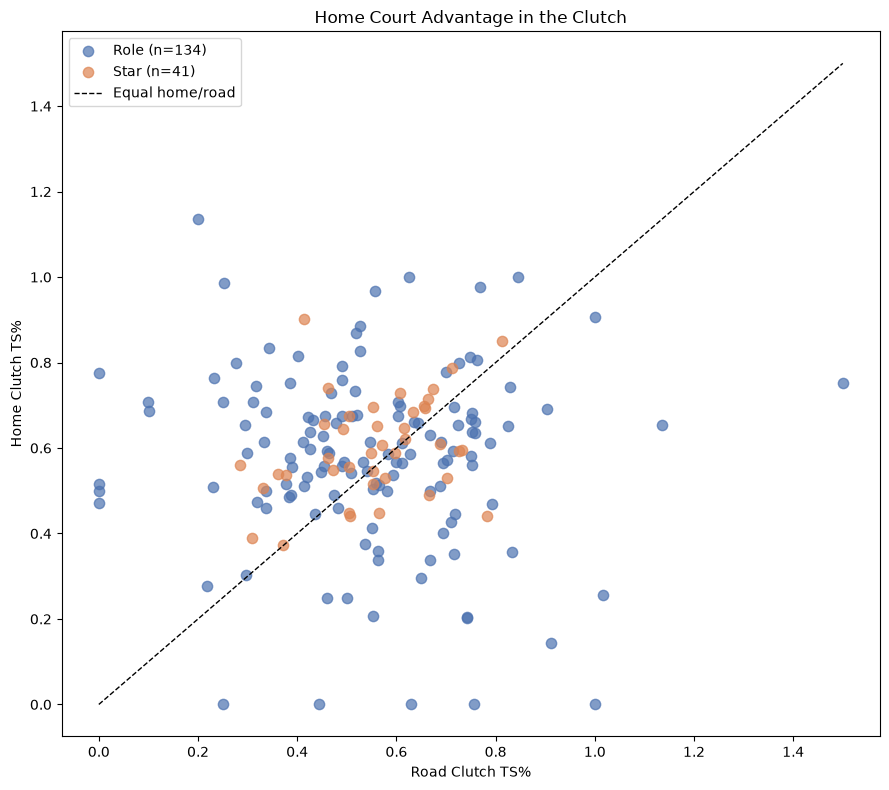

In [32]:
fig, ax = plt.subplots(figsize=(9, 8))
c2 = {'Role': '#4C72B0', 'Star': '#DD8452'}

for tier, sub in hr.groupby('tier2'):
    ax.scatter(sub['TS_PCT_ROAD'], sub['TS_PCT_HOME'],
               label=f'{tier} (n={len(sub)})', alpha=0.7, s=55, color=c2[tier])

lims = [hr[['TS_PCT_HOME', 'TS_PCT_ROAD']].min().min(),
        hr[['TS_PCT_HOME', 'TS_PCT_ROAD']].max().max()]
ax.plot(lims, lims, 'k--', linewidth=1, label='Equal home/road')

ax.set_xlabel('Road Clutch TS%')
ax.set_ylabel('Home Clutch TS%')
ax.set_title('Home Court Advantage in the Clutch')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 14 — Home court swing in clutch net rating
**Interpret cautiously** — clutch net ratings swing ±30 on small samples;
taking the difference of two noisy numbers compounds that. Check
`hr.groupby('tier2')['NET_GAP'].std()` alongside this chart.

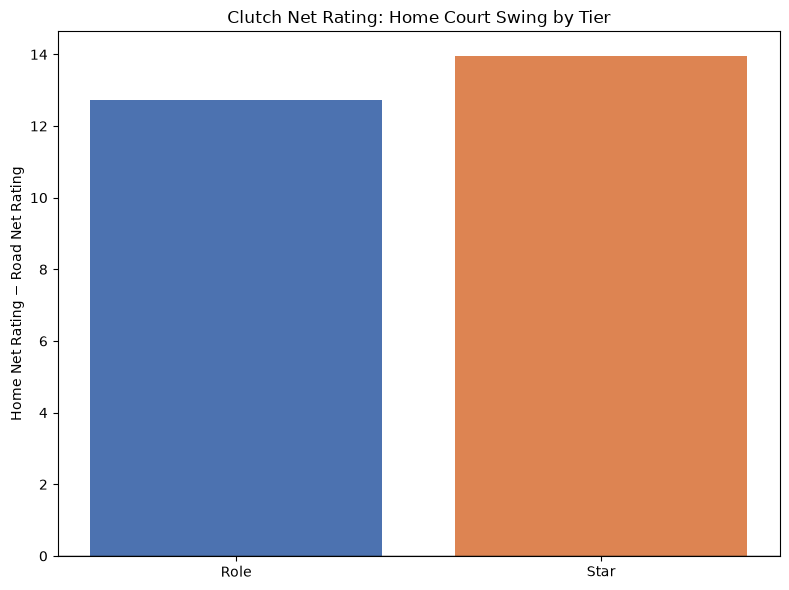

In [33]:
hr['NET_GAP'] = hr['NET_RATING_HOME'] - hr['NET_RATING_ROAD']
gap = hr.groupby('tier2')['NET_GAP'].mean().reindex(['Role', 'Star'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(gap.index, gap, color=['#4C72B0', '#DD8452'])
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Home Net Rating − Road Net Rating')
ax.set_title('Clutch Net Rating: Home Court Swing by Tier')
plt.tight_layout()
plt.show()

## Volume vs. Efficiency
> *Do stars absorb more clutch usage, and does it cost them efficiency?*

### Chart 15 — Season-long volume vs efficiency tradeoff
*Stars should cluster right, at high usage. The question is whether they hold
efficiency there — this sets the baseline pattern before pressure is added.*

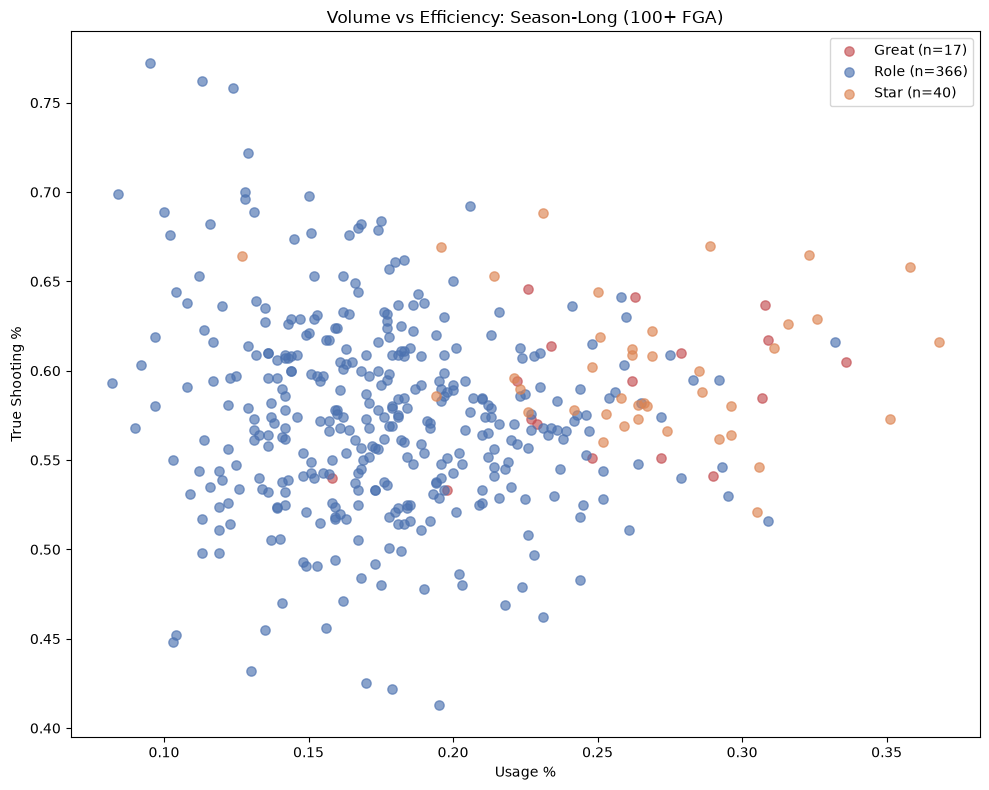

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))
for grp, sub in season_df.groupby('group'):
    ax.scatter(sub['USG_PCT'], sub['TS_PCT'], label=f'{grp} (n={len(sub)})',
               alpha=0.65, s=45, color=colors[grp])

ax.set_xlabel('Usage %')
ax.set_ylabel('True Shooting %')
ax.set_title('Volume vs Efficiency: Season-Long (100+ FGA)')
ax.legend()
plt.tight_layout()
plt.show()

### Chart 16 — Does clutch volume cost efficiency?
**The sharpest single test of the thesis.** *A downward slope — higher clutch
usage, bigger efficiency drop — is direct evidence that giving the star the
ball late is measurably costly.*

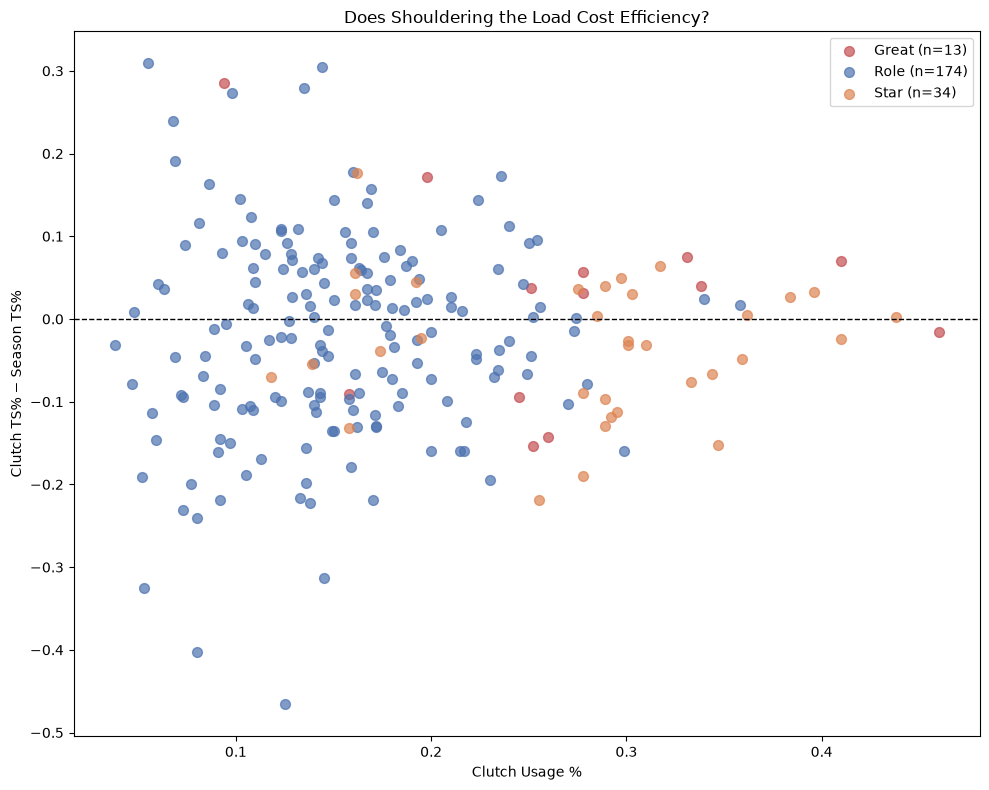

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
for grp, sub in df.groupby('group'):
    ax.scatter(sub['USG_PCT_CLUTCH'], sub['TS_DELTA'],
               label=f'{grp} (n={len(sub)})', alpha=0.7, s=50, color=colors[grp])

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Clutch Usage %')
ax.set_ylabel('Clutch TS% − Season TS%')
ax.set_title('Does Shouldering the Load Cost Efficiency?')
ax.legend()
plt.tight_layout()
plt.show()

## Trend Analysis
### Chart 17 — Does season efficiency predict clutch efficiency?
`qcut` bins by rank rather than value, so every quintile has an even count
regardless of the column's scale.

*The blue line rises by construction. The signal is the gap between the two
lines — a flatter red line means regression toward the mean, and some of that
is a real effect, some is a statistical artifact of small clutch samples. Don't
claim "elite shooters choke" from this chart alone.*

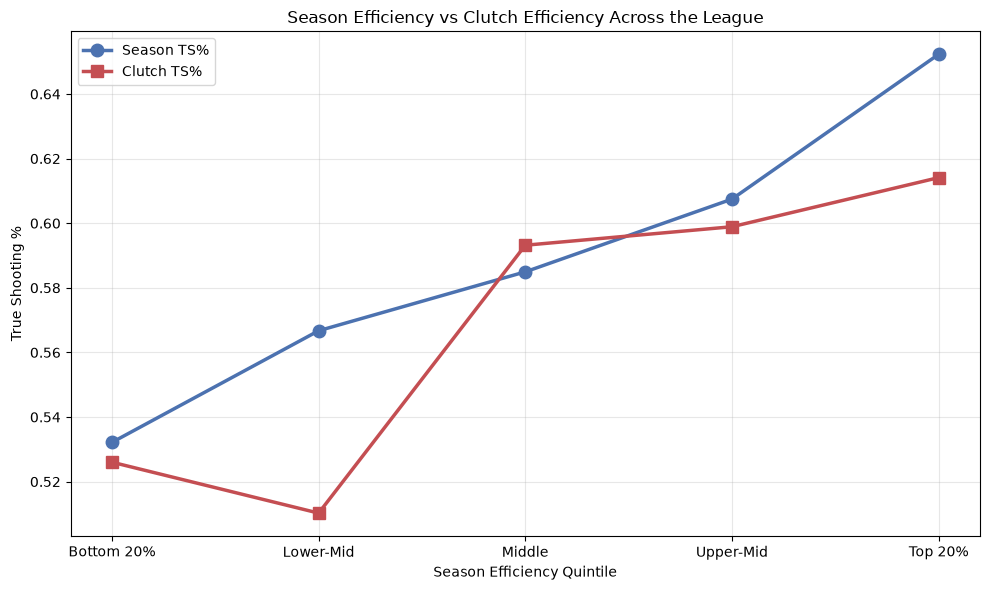

ts_quintile
Bottom 20%    45
Lower-Mid     46
Middle        42
Upper-Mid     45
Top 20%       43
dtype: int64


In [36]:
df['ts_quintile'] = pd.qcut(
    df['TS_PCT_SEASON'], q=5,
    labels=['Bottom 20%', 'Lower-Mid', 'Middle', 'Upper-Mid', 'Top 20%']
)

trend = df.groupby('ts_quintile', observed=True)[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].mean()
sizes = df.groupby('ts_quintile', observed=True).size()

fig, ax = plt.subplots(figsize=(10, 6))
x = [str(i) for i in trend.index]

ax.plot(x, trend['TS_PCT_SEASON'], marker='o', linewidth=2.5, markersize=9,
        label='Season TS%', color='#4C72B0')
ax.plot(x, trend['TS_PCT_CLUTCH'], marker='s', linewidth=2.5, markersize=9,
        label='Clutch TS%', color='#C44E52')

ax.set_xlabel('Season Efficiency Quintile')
ax.set_ylabel('True Shooting %')
ax.set_title('Season Efficiency vs Clutch Efficiency Across the League')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(sizes)

### Chart 18 — Same comparison, split by tier
*Controls for the obvious confound — stars are better players on average, so a
raw comparison flatters them. This compares stars and role players at matched
efficiency levels. If the star line sits below role at the same efficiency
level, stars get less out of clutch situations despite taking more shots.*

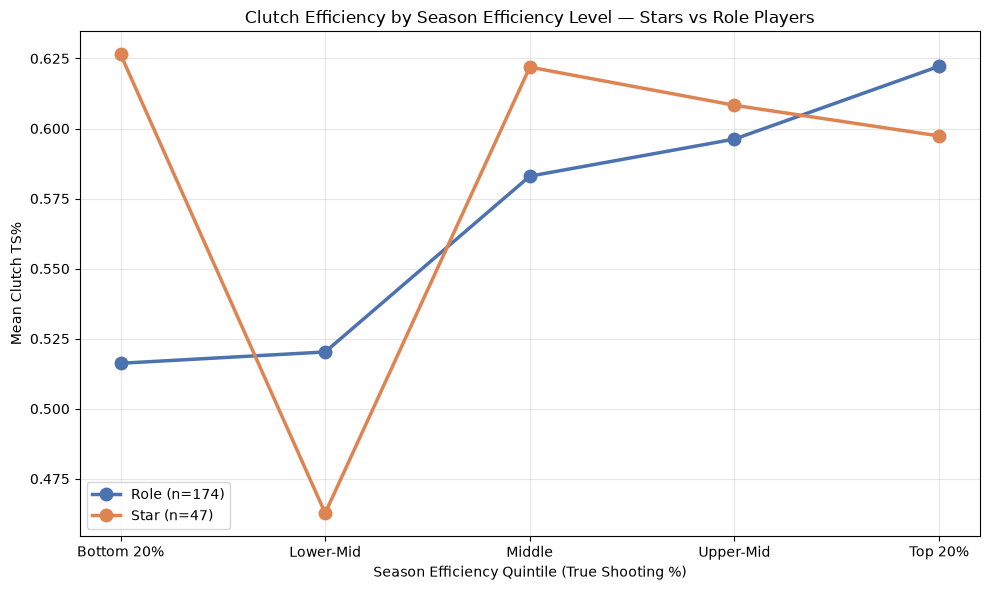

tier2        Role  Star
ts_quintile            
Bottom 20%     41     4
Lower-Mid      38     8
Middle         31    11
Upper-Mid      35    10
Top 20%        29    14


In [37]:
df['ts_quintile'] = pd.qcut(
    df['TS_PCT_SEASON'], q=5,
    labels=['Bottom 20%', 'Lower-Mid', 'Middle', 'Upper-Mid', 'Top 20%']
)

df['tier2'] = np.where(df['group'] == 'Role', 'Role', 'Star')

qt = df.groupby(['ts_quintile', 'tier2'], observed=True)['TS_PCT_CLUTCH'].mean().unstack()
qc = df.groupby(['ts_quintile', 'tier2'], observed=True).size().unstack(fill_value=0)
qt = qt.where(qc >= 3)

c2 = {'Role': '#4C72B0', 'Star': '#DD8452'}

fig, ax = plt.subplots(figsize=(10, 6))
for tier in ['Role', 'Star']:
    if tier in qt.columns:
        s = qt[tier].dropna()
        if len(s) >= 2:
            ax.plot([str(i) for i in s.index], s.values, marker='o',
                    linewidth=2.5, markersize=9,
                    label=f'{tier} (n={qc[tier].sum()})', color=c2[tier])

ax.set_xlabel('Season Efficiency Quintile (True Shooting %)')
ax.set_ylabel('Mean Clutch TS%')
ax.set_title('Clutch Efficiency by Season Efficiency Level — Stars vs Role Players')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(qc)

### Chart 19 — Clutch efficiency by clutch shot volume
*Isolates volume from talent. If both lines decline as volume rises, the
effect is about difficulty of high-volume late shots generally, not about who's taking them.*

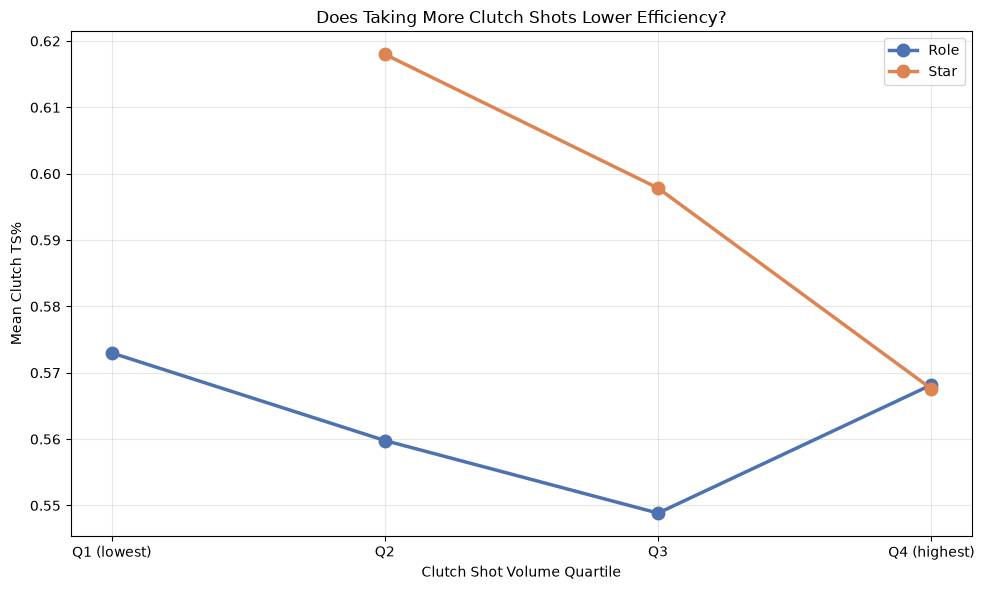

In [38]:
df['fga_quartile'] = pd.qcut(df['FGA_CLUTCH'], q=4,
                             labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

wt = df.groupby(['fga_quartile', 'tier2'], observed=True)['TS_PCT_CLUTCH'].mean().unstack()
wc = df.groupby(['fga_quartile', 'tier2'], observed=True).size().unstack(fill_value=0)
wt = wt.where(wc >= 3)

fig, ax = plt.subplots(figsize=(10, 6))
for tier in ['Role', 'Star']:
    if tier in wt.columns:
        s = wt[tier].dropna()
        if len(s) >= 2:
            ax.plot([str(i) for i in s.index], s.values, marker='o',
                    linewidth=2.5, markersize=9, label=tier, color=c2[tier])

ax.set_xlabel('Clutch Shot Volume Quartile')
ax.set_ylabel('Mean Clutch TS%')
ax.set_title('Does Taking More Clutch Shots Lower Efficiency?')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
print(wc)

tier2         Role  Star
fga_quartile            
Q1 (lowest)     57     2
Q2              53     3
Q3              40    12
Q4 (highest)    24    30


### Chart 20 — Usage shift by tier: the closing argument
Solid = season usage, dashed = clutch usage, same color = same tier.
*The vertical gap within each color pair is how much that tier's workload
grows under pressure — if star dashed jumps well above star solid while role
stays flat, offenses are demonstrably concentrating clutch touches on stars.*

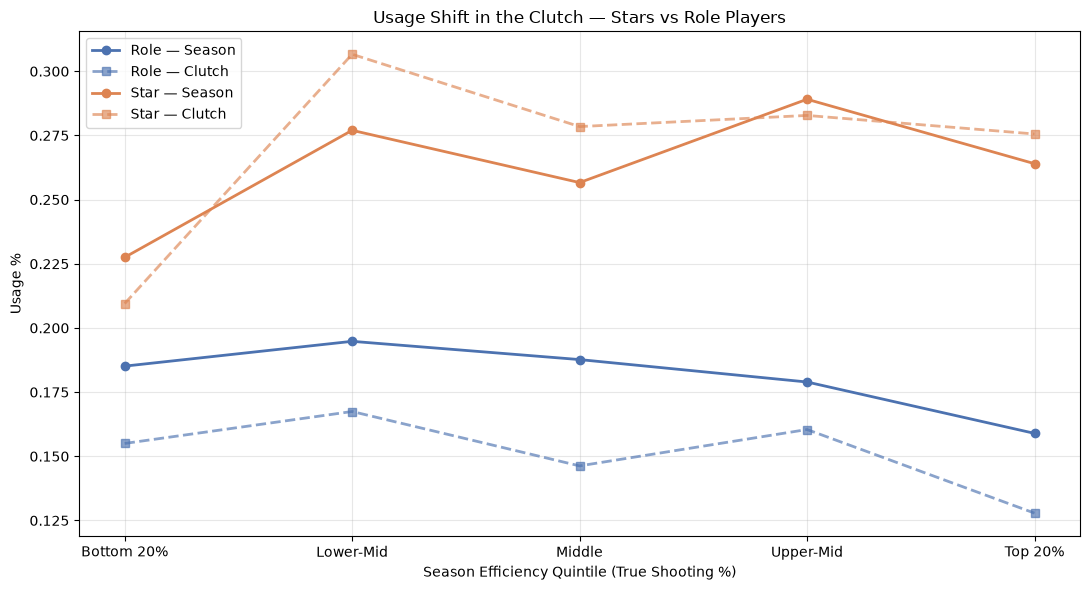

In [40]:
uq = df.groupby(['ts_quintile', 'tier2'], observed=True)[['USG_PCT_SEASON', 'USG_PCT_CLUTCH']].mean()

fig, ax = plt.subplots(figsize=(11, 6))
for tier in ['Role', 'Star']:
    sub = uq.xs(tier, level='tier2')
    x = [str(i) for i in sub.index]
    ax.plot(x, sub['USG_PCT_SEASON'], marker='o', linewidth=2,
            label=f'{tier} — Season', color=c2[tier])
    ax.plot(x, sub['USG_PCT_CLUTCH'], marker='s', linewidth=2, linestyle='--',
            label=f'{tier} — Clutch', color=c2[tier], alpha=0.65)

ax.set_xlabel('Season Efficiency Quintile (True Shooting %)')
ax.set_ylabel('Usage %')
ax.set_title('Usage Shift in the Clutch — Stars vs Role Players')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#E8E8E8',
    'grid.linewidth': 0.8,
    'xtick.bottom': False,
    'ytick.left': False,
})

NAVY  = '#2B4570'   # Role
ORANGE= '#E07A3F'   # Star
TEAL  = '#2A9D8F'   # Great
MUTED = '#C9CCD1'   # de-emphasized

TIER_C = {'Role': NAVY, 'Star': ORANGE, 'Great': TEAL}

def titled(ax, headline, sub):
    """Big takeaway line + smaller descriptive line."""
    ax.set_title(headline, fontsize=15, fontweight='bold', loc='left', pad=24)
    ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=10.5,
            color='#666', ha='left', va='bottom')

## Key Insight 1 — Stars Fall Off the Most in the Clutch

`Chart 5`

Every tier shoots worse when the game tightens, but not equally. Star players
show the steepest drop in True Shooting % between their season average and
their clutch performance — more than role players, and in the opposite
direction from Greats, who actually improve.

The gap isn't massive, but the direction is clear: the tier with the biggest
reputation for clutch performance is the one falling off the most.

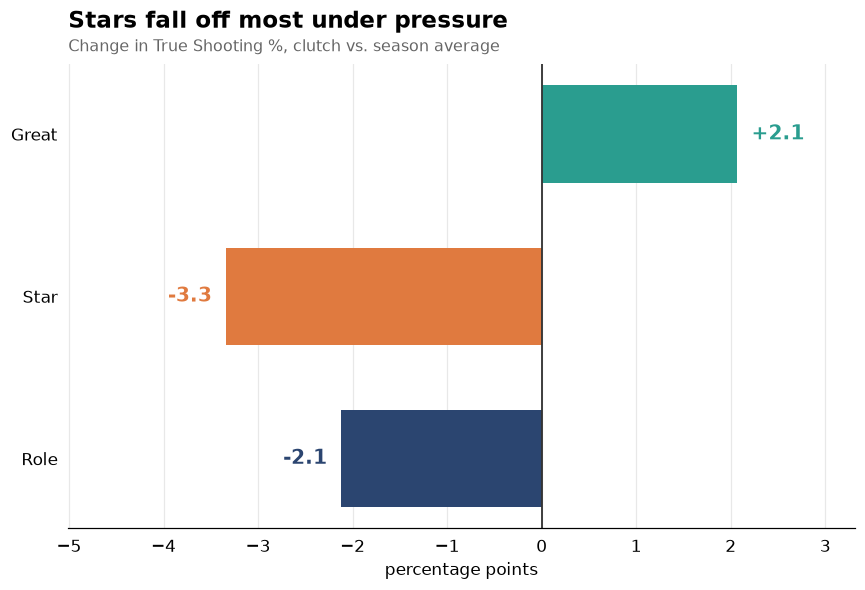

In [42]:
order = ['Role', 'Star', 'Great']
d = (df.groupby('group')['TS_DELTA'].mean() * 100).reindex(order)

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(order, d.values, color=[TIER_C[g] for g in order], height=0.6)
ax.axvline(0, color='#333', linewidth=1.2)

for bar, val in zip(bars, d.values):
    ax.text(val + (0.15 if val >= 0 else -0.15), bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right',
            fontweight='bold', fontsize=13, color=bar.get_facecolor())

titled(ax, 'Stars fall off most under pressure',
       'Change in True Shooting %, clutch vs. season average')
ax.set_xlabel('percentage points')
ax.set_xlim(min(d.min()*1.5, -1), max(d.max()*1.6, 1))
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## Key Insight 2 — Stars Get More Shots and Make Fewer of Them

`Chart 8`

When games get close and late, offenses shift possession toward stars and away
from role players. Star usage climbs in the clutch while role player usage
drops — the ball is being deliberately funneled upward through the reputation
hierarchy.

The problem: star shooting efficiency moves in the opposite direction of their
usage. More shots, worse results. Role players lose the ball at the same moment
their shooting would suggest they've earned more of it.

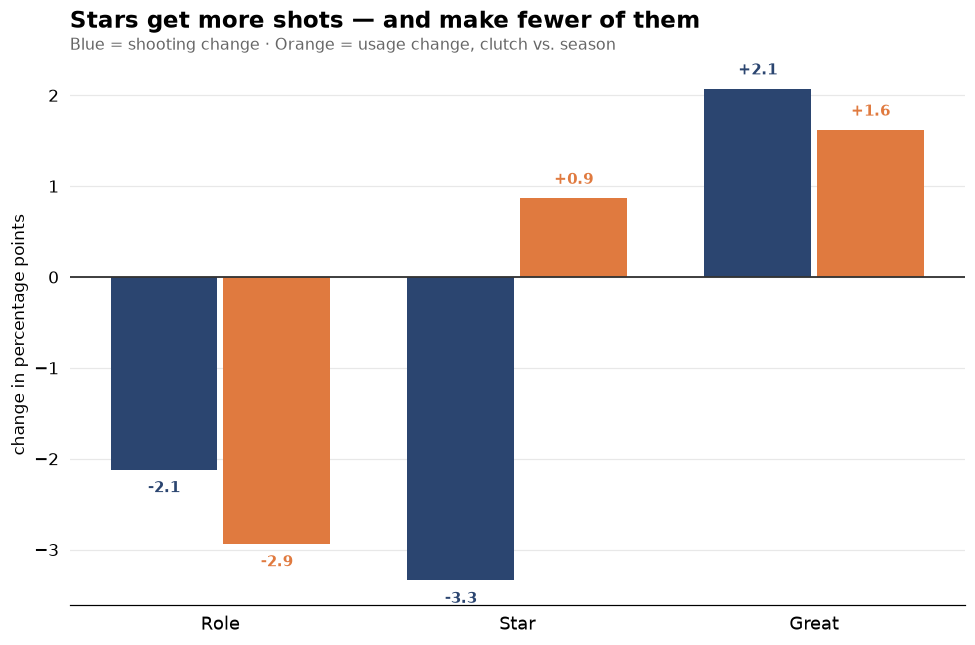

In [43]:
ts_d  = (df.groupby('group')['TS_DELTA'].mean() * 100).reindex(order)
usg_d = (df.groupby('group')['USG_DELTA'].mean() * 100).reindex(order)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(order))

ax.bar(x - 0.19, ts_d, 0.36, color=NAVY, label='Shooting %')
ax.bar(x + 0.19, usg_d, 0.36, color=ORANGE, label='Usage %')
ax.axhline(0, color='#333', linewidth=1.2)

for xi, (t, u) in enumerate(zip(ts_d, usg_d)):
    ax.text(xi - 0.19, t + (0.12 if t >= 0 else -0.12), f'{t:+.1f}',
            ha='center', va='bottom' if t >= 0 else 'top', fontsize=10, color=NAVY, fontweight='bold')
    ax.text(xi + 0.19, u + (0.12 if u >= 0 else -0.12), f'{u:+.1f}',
            ha='center', va='bottom' if u >= 0 else 'top', fontsize=10, color=ORANGE, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(order, fontsize=12)
ax.set_ylabel('change in percentage points')
titled(ax, 'Stars get more shots — and make fewer of them',
       'Blue = shooting change · Orange = usage change, clutch vs. season')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

## Key Insight 3 — The Biggest Swings Belong to Role Players

`Chart 9 & 10`

Looking at the 15 biggest clutch risers and 15 biggest fallers — 30 slots
total — stars appear far less often than their population share would predict.
The dramatic individual performances, both heroic and disastrous, are
overwhelmingly a role player story.

The two Greats who do appear both land on the risers list, consistent with
Insight 1 — the Olympic Gold tier is the one group that reliably elevates.

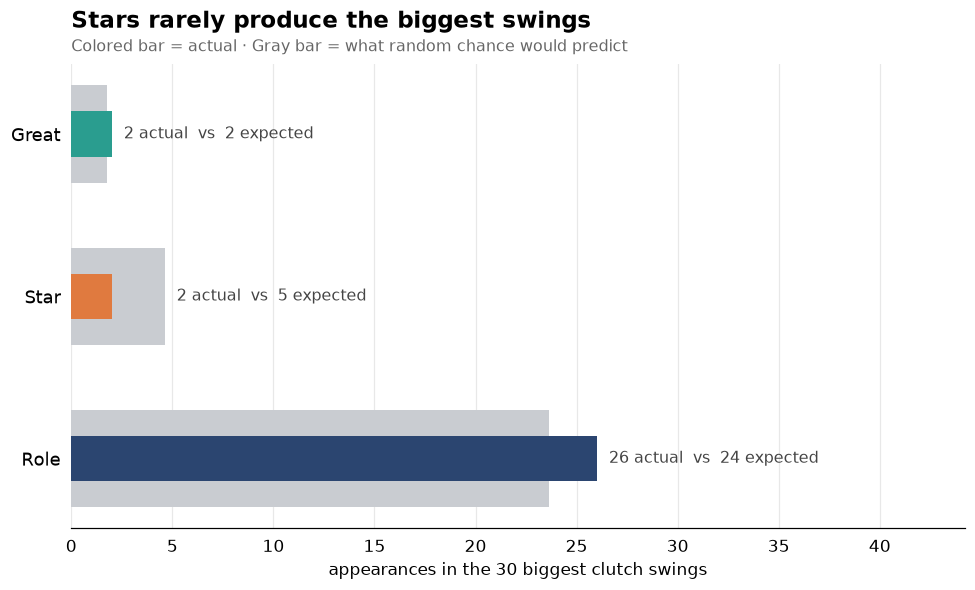

In [44]:
risers  = df.nlargest(15, 'TS_DELTA')['group'].value_counts().reindex(order, fill_value=0)
fallers = df.nsmallest(15, 'TS_DELTA')['group'].value_counts().reindex(order, fill_value=0)
actual  = risers + fallers

share = df['group'].value_counts().reindex(order)
expected = (share / share.sum()) * 30

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(order))

ax.barh(y, expected, 0.6, color=MUTED, label='expected')
ax.barh(y, actual, 0.28, color=[TIER_C[g] for g in order])

for yi, (a, e) in enumerate(zip(actual, expected)):
    ax.text(max(a, e) + 0.6, yi, f'{a:.0f} actual  vs  {e:.0f} expected',
            va='center', fontsize=10.5, color='#444')

ax.set_yticks(y); ax.set_yticklabels(order, fontsize=12)
ax.set_xlabel('appearances in the 30 biggest clutch swings')
titled(ax, 'Stars rarely produce the biggest swings',
       'Colored bar = actual · Gray bar = what random chance would predict')
ax.set_xlim(0, max(actual.max(), expected.max()) * 1.7)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## Key Insight 4 — Home Court Helps, But Equally

`Chart 12`

Both tiers shoot better in clutch situations at home than on the road. The
gap is real — but it's roughly the same size for stars and role players alike.

This rules out venue as an explanation for the other findings. Whatever is
driving the efficiency and usage patterns in Insights 1 and 2, it isn't the
crowd or the travel schedule. The reputation effect shows up home and road
equally.

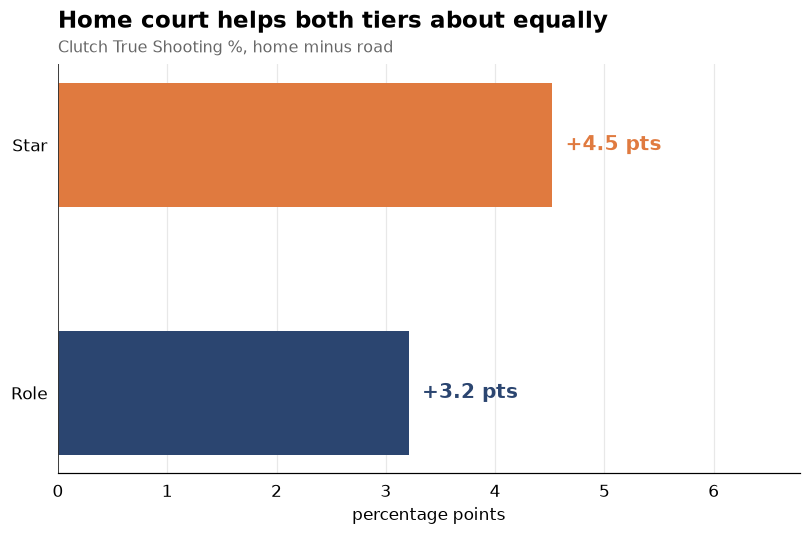

In [45]:
gap = (hr.groupby('tier2')['TS_HOME_ROAD_GAP'].mean() * 100).reindex(['Role', 'Star'])

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.barh(gap.index, gap.values, color=[NAVY, ORANGE], height=0.5)
ax.axvline(0, color='#333', linewidth=1.2)

for bar, val in zip(bars, gap.values):
    ax.text(val + 0.12, bar.get_y() + bar.get_height()/2, f'+{val:.1f} pts',
            va='center', fontweight='bold', fontsize=13, color=bar.get_facecolor())

titled(ax, 'Home court helps both tiers about equally',
       'Clutch True Shooting %, home minus road')
ax.set_xlabel('percentage points')
ax.set_xlim(0, gap.max() * 1.5)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

## Key Insight 5 — At the Top, Role Players Out-Shoot Stars and Still Get Fewer Shots

`Chart 18 & 20`

Among the most efficient shooters in the league this season (top 20% by
season TS%), role players post a higher clutch True Shooting % than stars.
At the same time, their clutch usage gets cut the hardest of any quintile —
the offense pulls the ball away from them even as the numbers say they've
earned it.

The shaded band marks this top quintile in both panels. Watch what happens
there: the shooting lines cross (role above star) while the usage lines stay
fixed apart (star well above role). The allocation and the performance are
moving in opposite directions.

This is the clearest version of the reputation-vs-performance gap this
project set out to test: at the skill level where the data most strongly
supports giving a role player the ball, the offense does the opposite.

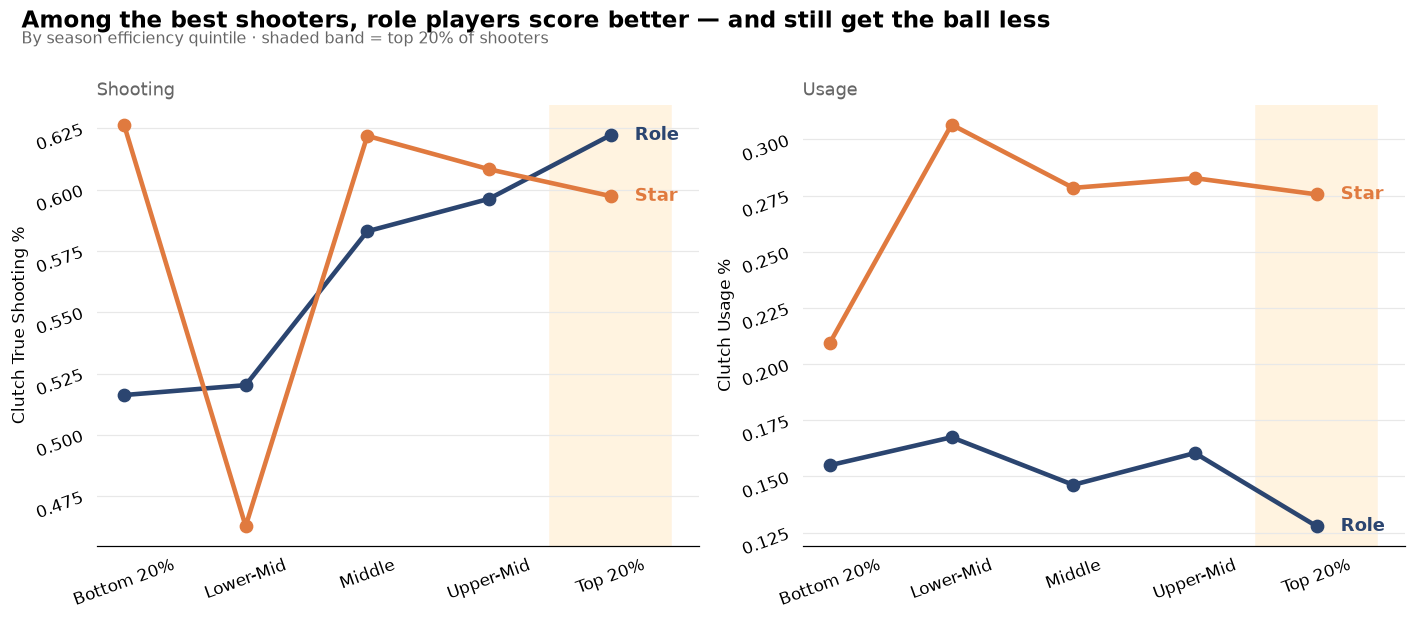

In [46]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)
xl = [str(i) for i in qt.index]

for tier in ['Role', 'Star']:
    s = qt[tier].dropna()
    a1.plot([str(i) for i in s.index], s.values, marker='o', markersize=8,
            linewidth=3, color=TIER_C[tier])
    a1.text(len(s) - 0.9, s.values[-1], f'  {tier}', color=TIER_C[tier],
            fontweight='bold', va='center', fontsize=12)

for tier in ['Role', 'Star']:
    sub = uq.xs(tier, level='tier2')
    a2.plot(xl, sub['USG_PCT_CLUTCH'].values, marker='o', markersize=8,
            linewidth=3, color=TIER_C[tier])
    a2.text(len(xl) - 0.9, sub['USG_PCT_CLUTCH'].values[-1], f'  {tier}',
            color=TIER_C[tier], fontweight='bold', va='center', fontsize=12)

for a in (a1, a2):
    a.axvspan(3.5, 4.5, color='#FFF3E0', zorder=0)   # highlight Top 20%
    a.tick_params(labelrotation=20)
    a.grid(axis='x', visible=False)

a1.set_ylabel('Clutch True Shooting %')
a2.set_ylabel('Clutch Usage %')
a1.set_title('Shooting', fontsize=12, color='#666', loc='left')
a2.set_title('Usage', fontsize=12, color='#666', loc='left')

fig.suptitle('Among the best shooters, role players score better — and still get the ball less',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.02)
fig.text(0.02, 0.965, 'By season efficiency quintile · shaded band = top 20% of shooters',
         fontsize=10.5, color='#666')
plt.tight_layout()
plt.show()

In [47]:
risers_detail = df.nlargest(10, 'TS_DELTA')[[
    'PLAYER_NAME', 'group', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH',
    'TS_DELTA', 'USG_PCT_SEASON', 'USG_PCT_CLUTCH', 'USG_DELTA',
    'NET_RATING_CLUTCH', 'PIE_CLUTCH', 'GP_CLUTCH'
]]

fallers_detail = df.nsmallest(10, 'TS_DELTA')[[
    'PLAYER_NAME', 'group', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH',
    'TS_DELTA', 'USG_PCT_SEASON', 'USG_PCT_CLUTCH', 'USG_DELTA',
    'NET_RATING_CLUTCH', 'PIE_CLUTCH', 'GP_CLUTCH'
]]

print("RISERS")
print(risers_detail.to_string())
print("\nFALLERS")
print(fallers_detail.to_string())

RISERS
          PLAYER_NAME  group  TS_PCT_SEASON  TS_PCT_CLUTCH  TS_DELTA  USG_PCT_SEASON  USG_PCT_CLUTCH  USG_DELTA  NET_RATING_CLUTCH  PIE_CLUTCH  GP_CLUTCH
297    Moussa Diabaté   Role          0.653          0.962     0.309           0.112           0.055     -0.057               -0.7       0.119         21
42   Brice Sensabaugh   Role          0.590          0.895     0.305           0.244           0.144     -0.100                5.6       0.171         16
110    Draymond Green  Great          0.540          0.825     0.285           0.158           0.094     -0.064               -3.5       0.095         28
298      Myles Turner   Role          0.584          0.863     0.279           0.181           0.135     -0.046               13.2       0.128         29
188   Jaylin Williams   Role          0.597          0.870     0.273           0.153           0.098     -0.055               53.8       0.147         18
365      Sidy Cissoko   Role          0.514          0.753     0.239 

## Key Insight 6 - Why Are These Players Overperforming/Underperforming

**Risers (left):** every single player here saw their clutch usage *drop* —
every point sits left of center. These aren't players taking over the
offense; they're players being selective, only shooting when the look is
good, and converting at an exceptional rate as a result.

**Fallers (right):** usage change is inconsistent — some drop, some hold
steady, one or two even rise slightly — but efficiency collapses regardless.
Jaren Jackson Jr., the only Star in this list, barely sees his usage move at
all (+0.2 points) while his shooting falls off a cliff. The offense kept
feeding him at his normal rate through a cold stretch.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


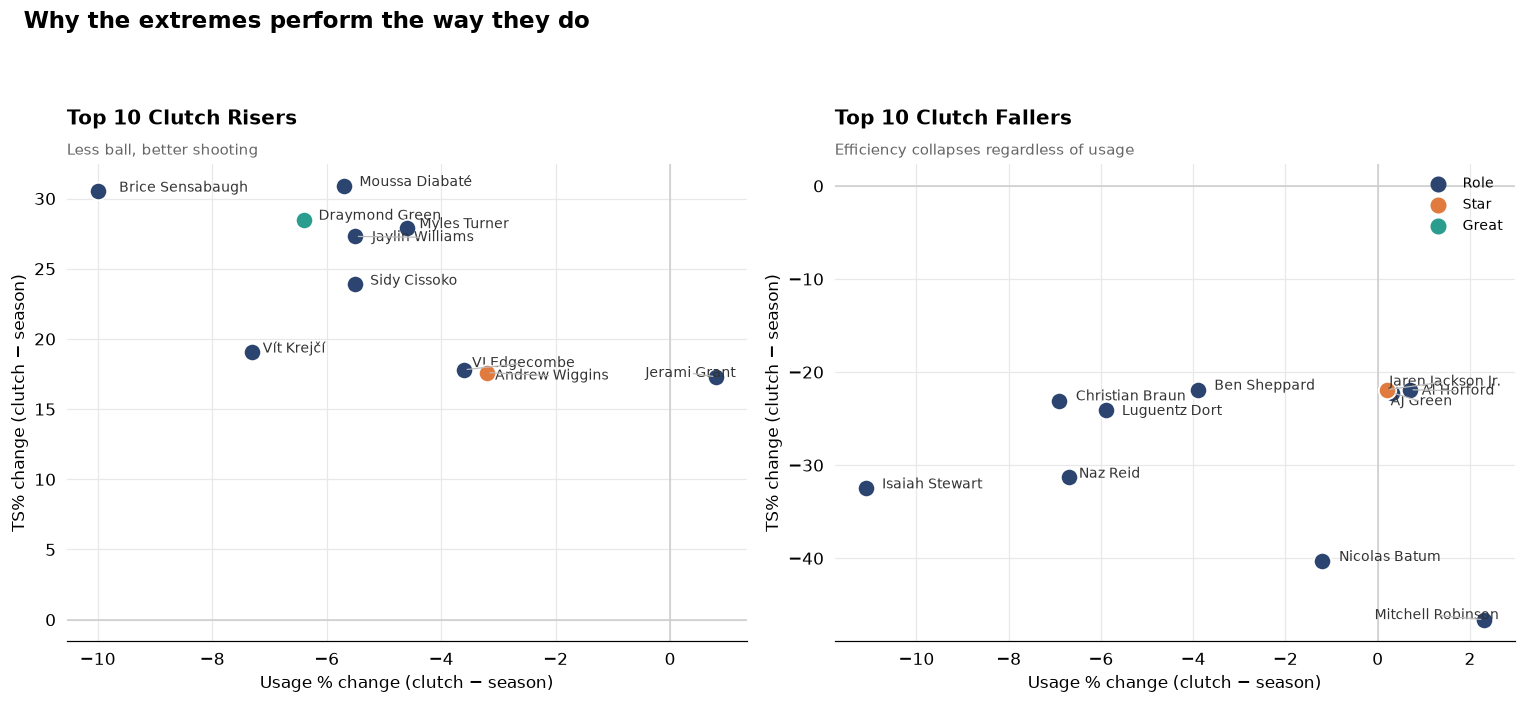

In [48]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, subset, title, note in [
    (a1, df.nlargest(10, 'TS_DELTA'), 'Top 10 Clutch Risers', 'Less ball, better shooting'),
    (a2, df.nsmallest(10, 'TS_DELTA'), 'Top 10 Clutch Fallers', 'Efficiency collapses regardless of usage')
]:
    s = subset.copy()
    s['TS_DELTA'] *= 100
    s['USG_DELTA'] *= 100

    texts = []
    for _, row in s.iterrows():
        ax.scatter(row['USG_DELTA'], row['TS_DELTA'],
                   color=TIER_C[row['group']], s=130, zorder=3,
                   edgecolor='white', linewidth=1.2)
        texts.append(ax.text(row['USG_DELTA'], row['TS_DELTA'],
                             row['PLAYER_NAME'], fontsize=9, color='#333'))

    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.8),
                expand_points=(1.4, 1.4))

    ax.axhline(0, color='#ccc', linewidth=1, zorder=1)
    ax.axvline(0, color='#ccc', linewidth=1, zorder=1)
    ax.set_xlabel('Usage % change (clutch − season)')
    ax.set_ylabel('TS% change (clutch − season)')
    ax.set_title(title, fontweight='bold', loc='left', fontsize=13, pad=26)
    ax.text(0, 1.02, note, transform=ax.transAxes, fontsize=9.5, color='#666')

for tier, color in TIER_C.items():
    a2.scatter([], [], color=color, label=tier, s=90)
a2.legend(loc='upper right', frameon=False, fontsize=9)

fig.suptitle('Why the extremes perform the way they do',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.06)
plt.tight_layout()
plt.show()